In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
from Utils.rfmap import load_rf_maps, RFMapList, asrfmap
from Utils.rf_trials import load_regular_rf_trials
from Utils.plotting import apply_light_plot_style
from scipy.ndimage import gaussian_filter
from plotting import plot_2d_rfmap
from matplotlib import pyplot as plt

apply_light_plot_style()

In [ ]:
base_dir: Path = Path("/mnt/senzailab/Kai/#Recording/m18/")
date = 260812

sessionID = 3
probeList = ("A", )
targetProbe = "A"
rf_time_range = (0.0, 0.2)
cluster_forming_z = 1.5

session_dir = base_dir / str(date)
hd_session = session_dir / f"{date}_1"
rf_session = session_dir / f"{date}_{sessionID}"

In [ ]:
rf_maps_by_probe = {}
summed_rf_maps_by_probe = {}
rf_trials_by_probe = {}
rf_centers_by_probe = {}
rfs_by_probe = {}

for probe in probeList:
    rf_json_path = (
            rf_session
            / "data/rfmapping/good/-100_400_1ms"
            / f"Probe{probe}"
            / f"regular_unitsSpikeCounts_{date}_{sessionID}.json"
    )
    raw = load_rf_maps(rf_json_path)
    summed = raw.sum(*rf_time_range)
    zero_unit_offsets = np.unique(summed.where(0)[0])
    keep_unit_mask = np.ones(summed.n_units, dtype=bool, )
    keep_unit_mask[zero_unit_offsets] = False

    excluded_unit_ids = np.asarray(summed.unit_ids)[zero_unit_offsets]
    raw = RFMapList([rf_map for rf_map, keep in zip(
        raw, keep_unit_mask, strict=True, ) if keep], raw.source_path, )

    summed = raw.sum(*rf_time_range)

    print(f"Kept {summed.n_units} in Probe{probe}")

    result = summed.rf_2d(
        trials=(trials := load_regular_rf_trials(rf_session, probe, summed)),
        is_shuffle=True,
        cluster_forming_z=cluster_forming_z,
    )
    center = summed.rf_2d(
        trials=(trials := load_regular_rf_trials(rf_session, probe, summed)),
        is_shuffle=True,
        cluster_forming_z=cluster_forming_z,
        return_center=True,
    )

    rf_maps_by_probe[probe] = raw
    summed_rf_maps_by_probe[probe] = summed
    rfs_by_probe[probe] = result
    rf_centers_by_probe[probe] = center

rf_all = np.concatenate(
    [rfs_by_probe[probe] for probe in probeList],
    axis=0,
)

center_all = np.concatenate(
    [rf_centers_by_probe[probe] for probe in probeList],
    axis=0,
)

# Keep probe identity because unit IDs may overlap between probes.
RFunitPool = [
    (probe, unit_id)
    for probe in probeList
    for unit_id in rf_maps_by_probe[probe].unit_ids
]

print({probe: rfs_by_probe[probe].shape[0] for probe in probeList})

In [ ]:
target_unitID = 127
target_maps = summed_rf_maps_by_probe[targetProbe]
target_unit = target_maps.by_unit_id(target_unitID)
target_unit_index = target_maps.unit_ids.index(target_unitID)

target_unit_bump = rfs_by_probe[targetProbe][
    target_unit_index
]
target_unit_bump_x = np.any(target_unit_bump, axis=0).astype(np.uint8)

plot_2d_rfmap(target_unit.to_2d_array(), cmap="grey")

plot_2d_rfmap(target_unit_bump, cmap="grey")

('A', 26)


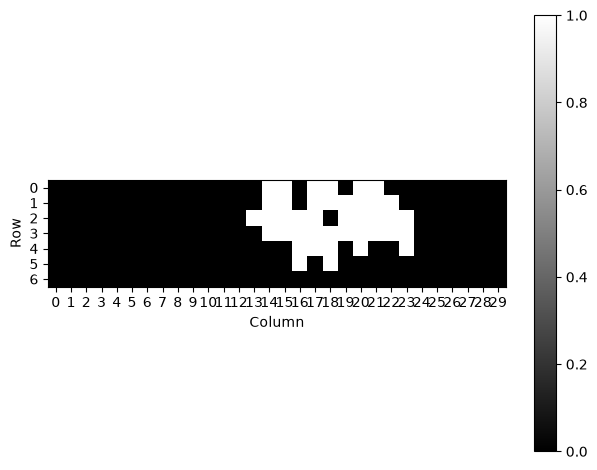

('A', 48)


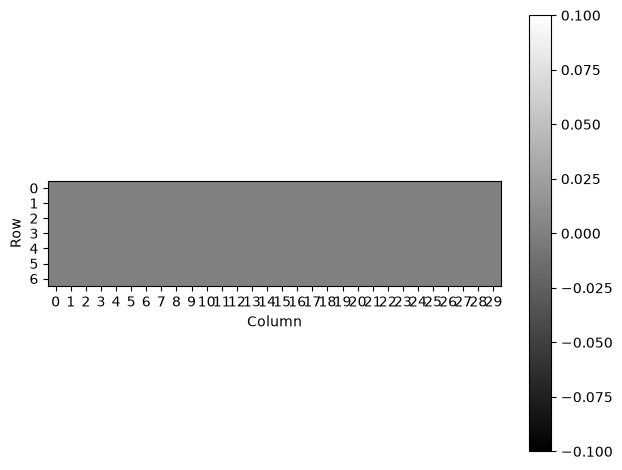

('A', 72)


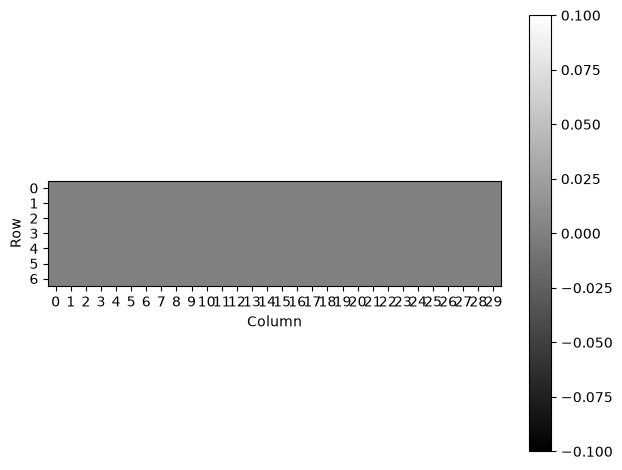

('A', 141)


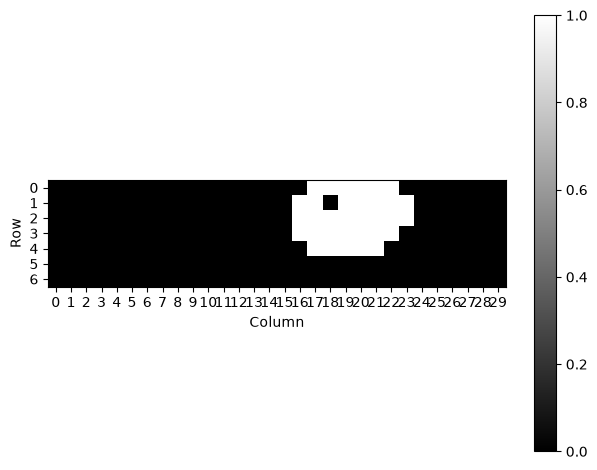

('A', 142)


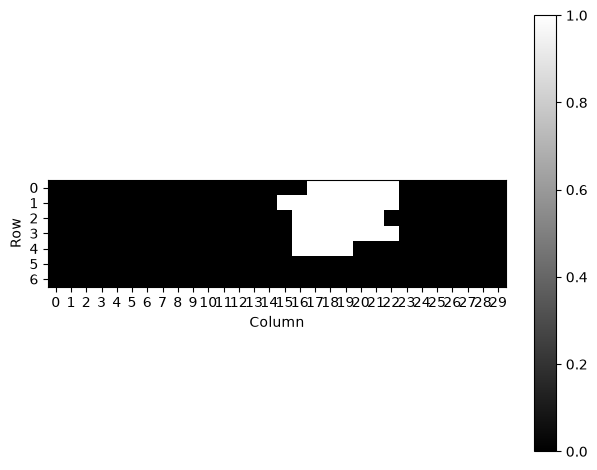

('A', 173)


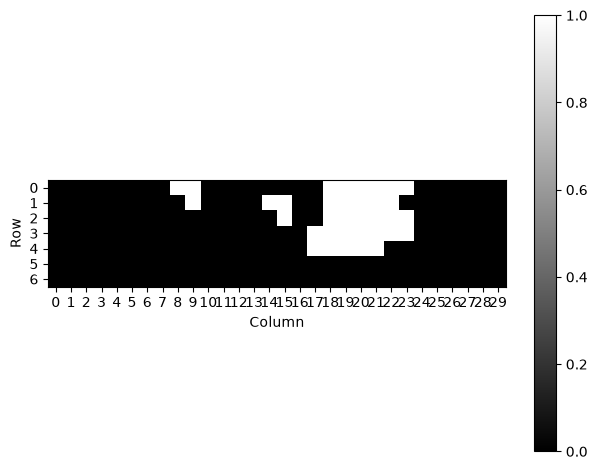

('A', 174)


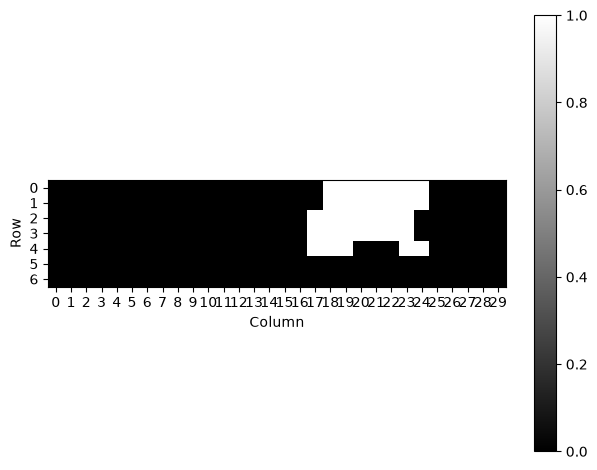

('A', 182)


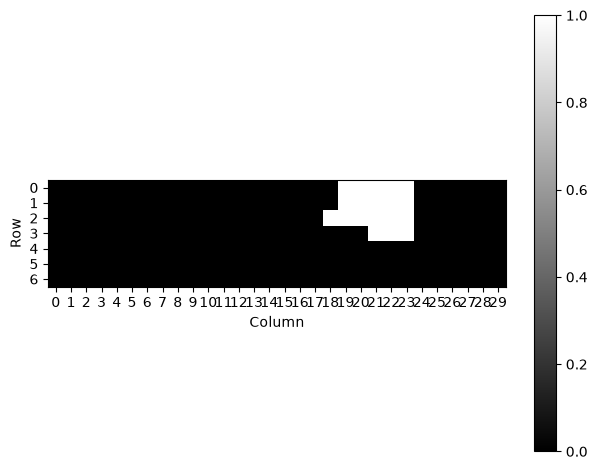

('A', 197)


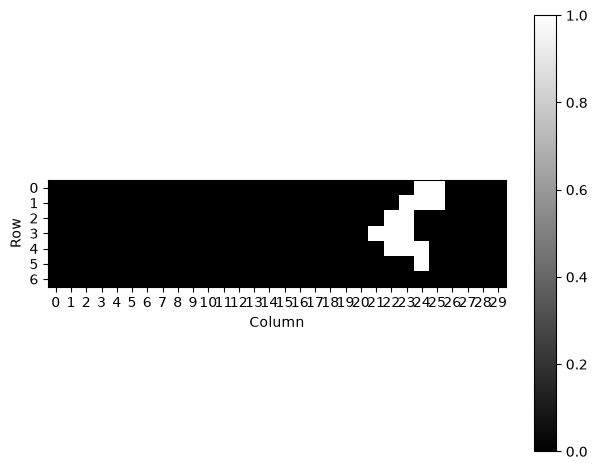

('A', 198)


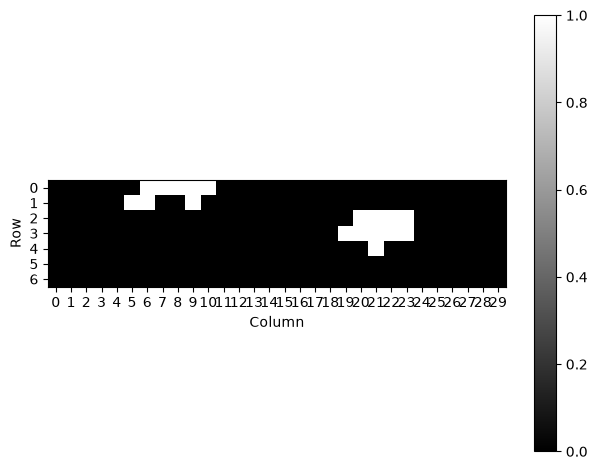

('A', 209)


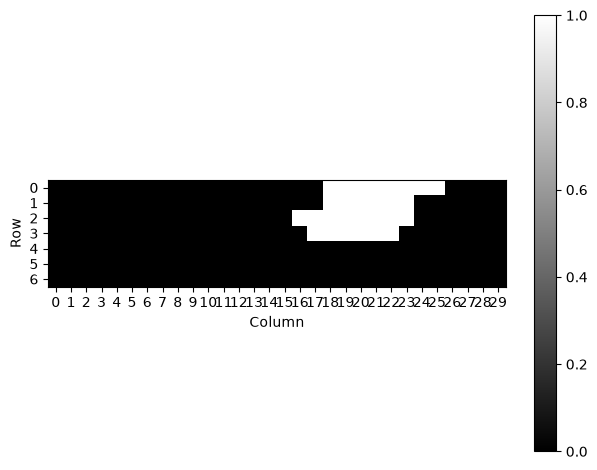

('A', 227)


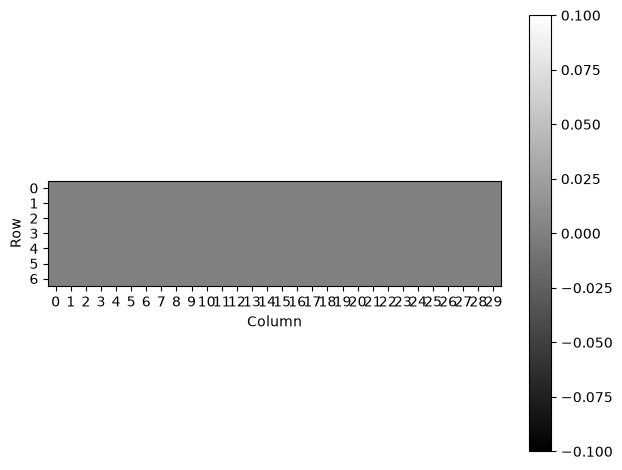

('A', 230)


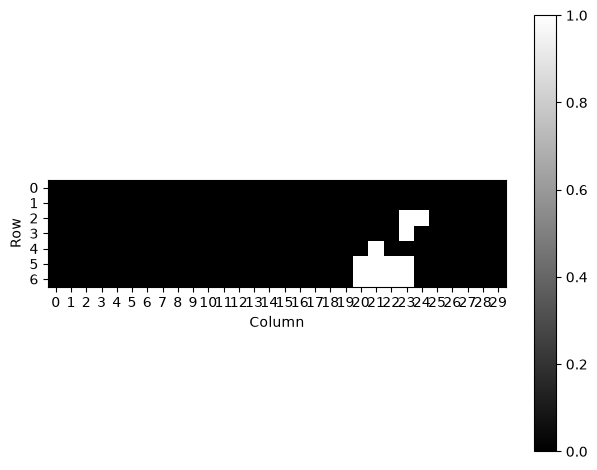

('A', 232)


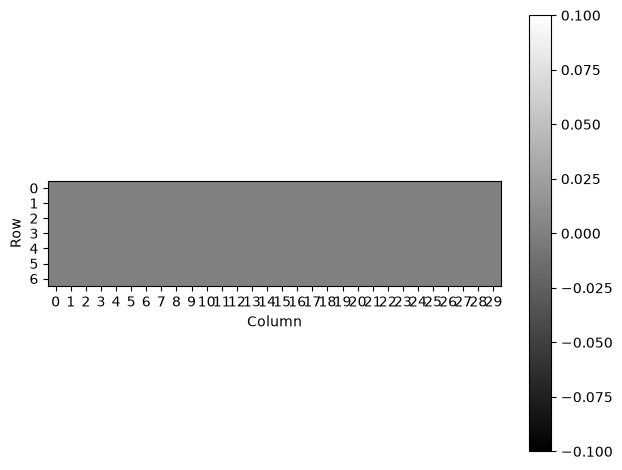

('A', 241)


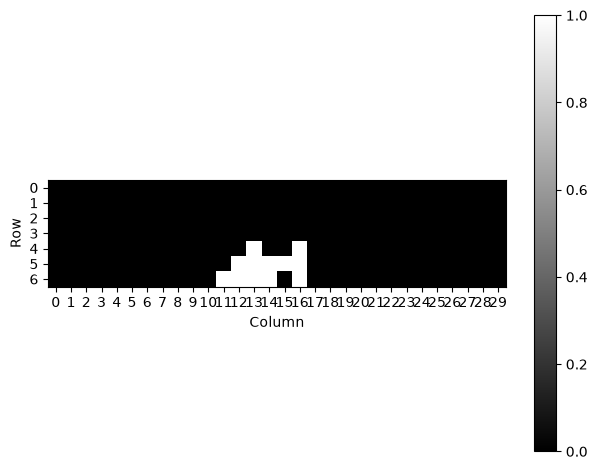

('A', 249)


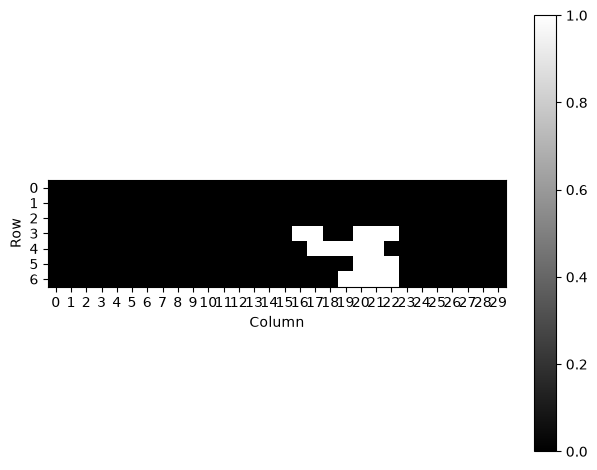

('A', 270)


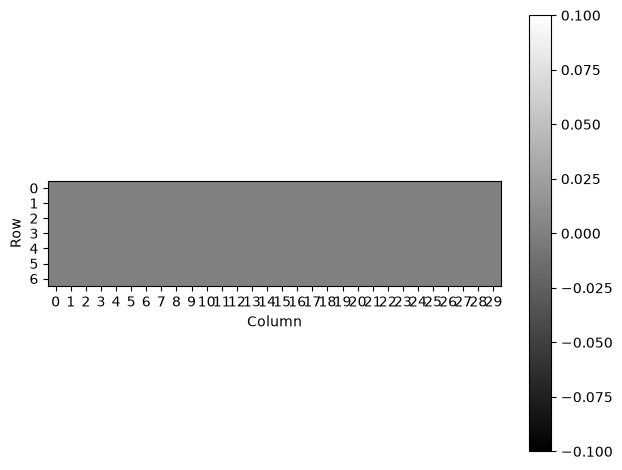

('A', 280)


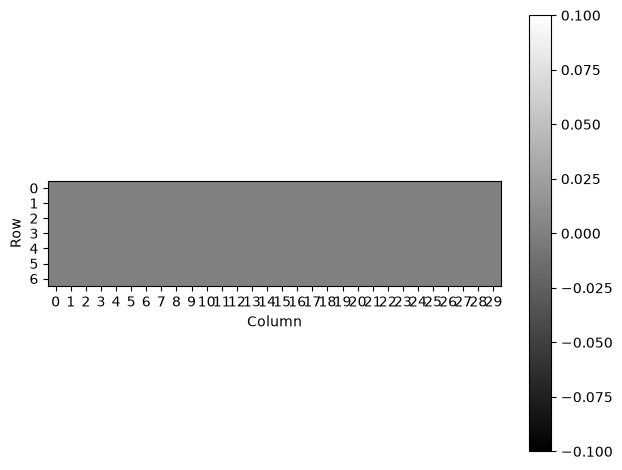

('A', 282)


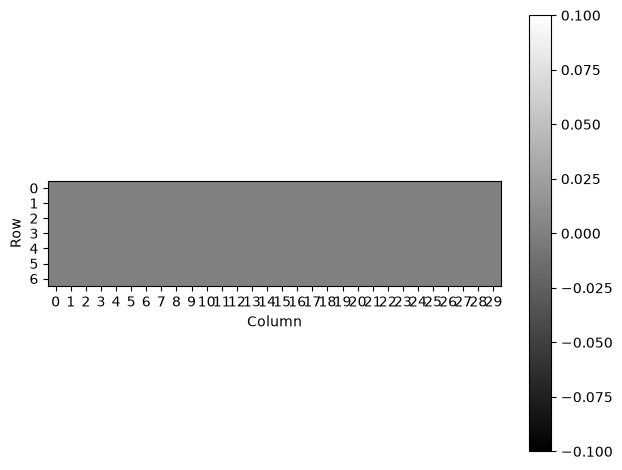

('A', 386)


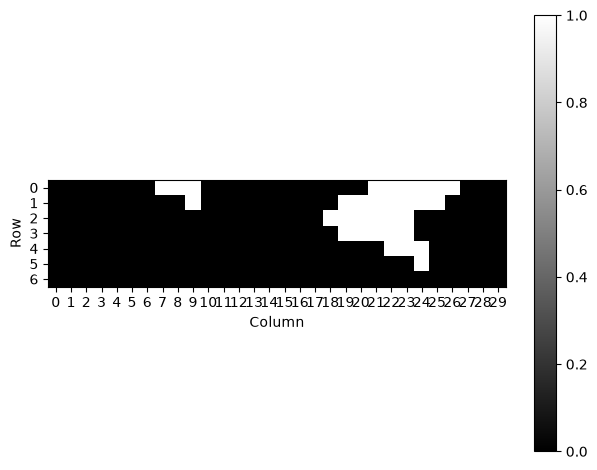

('A', 410)


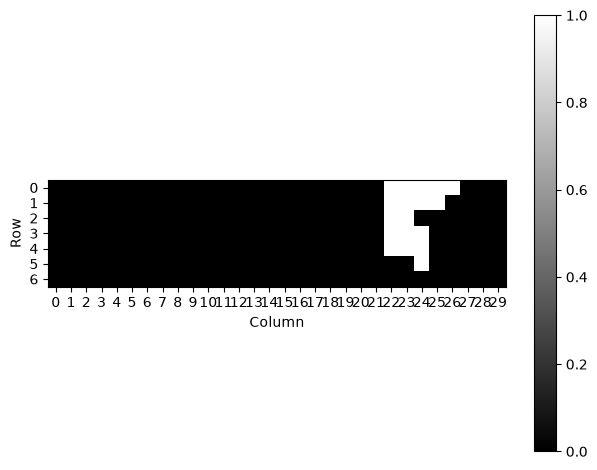

('A', 416)


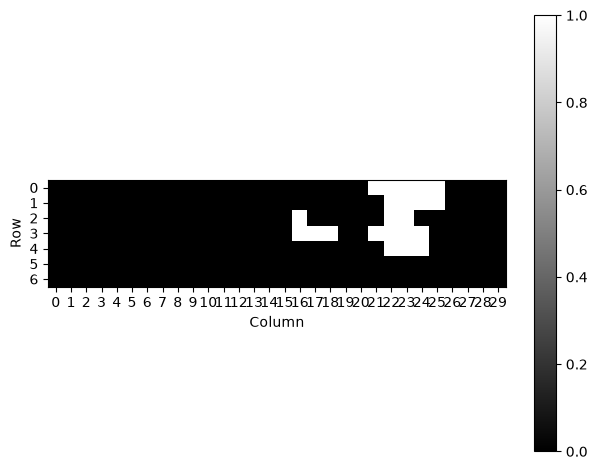

('A', 418)


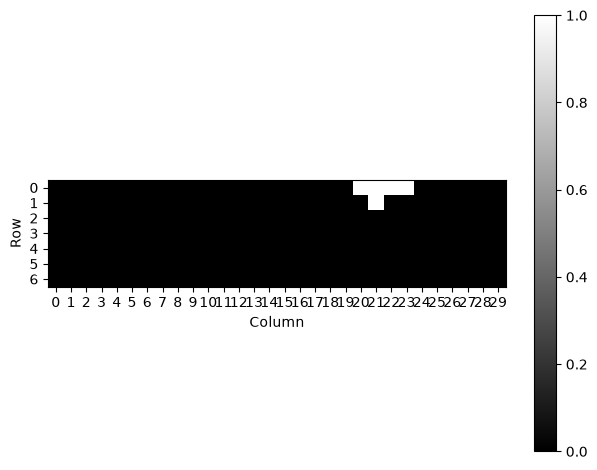

('A', 424)


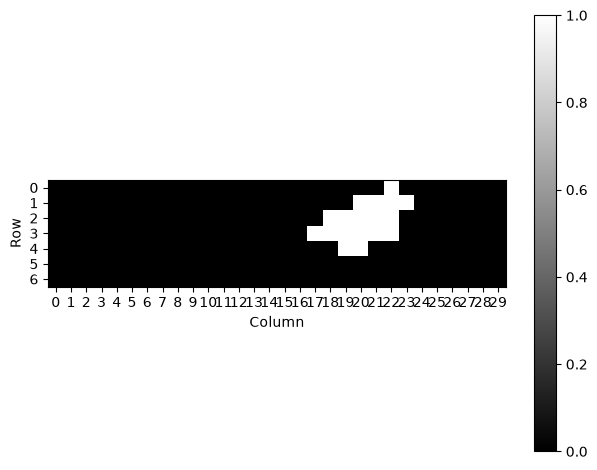

('A', 432)


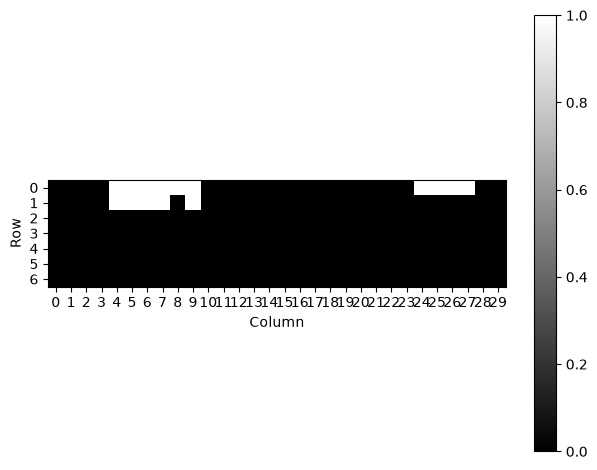

('A', 507)


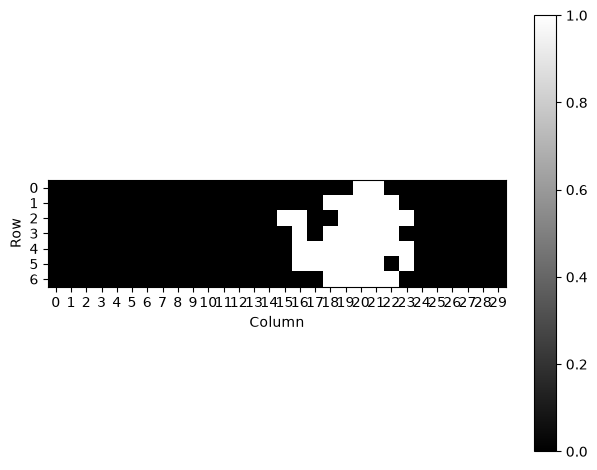

('A', 592)


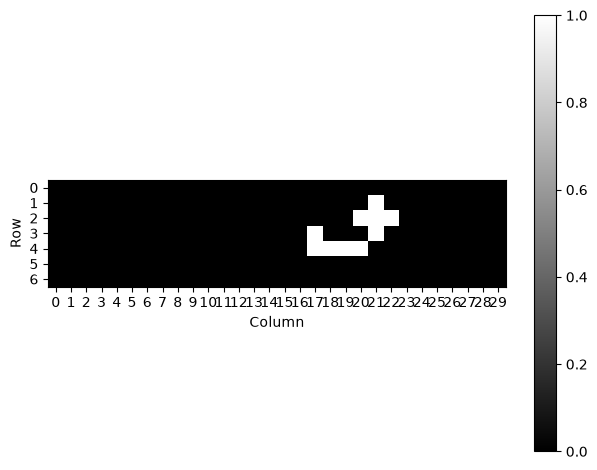

('A', 599)


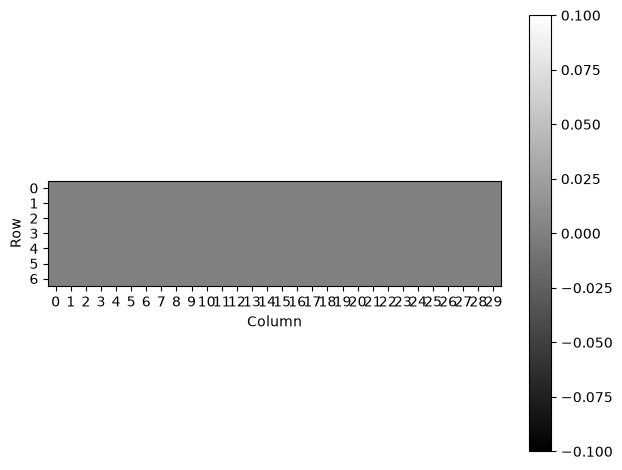

('A', 608)


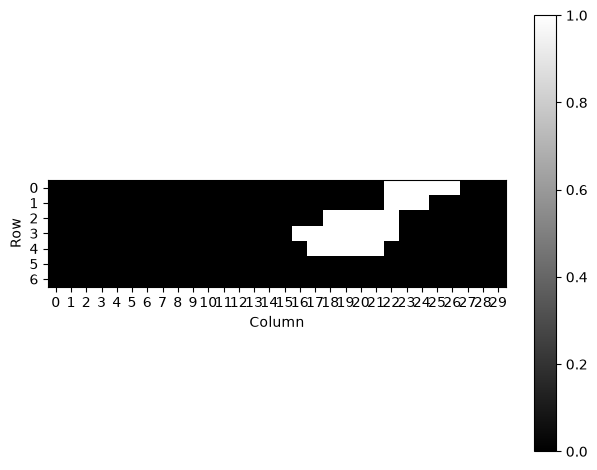

('A', 624)


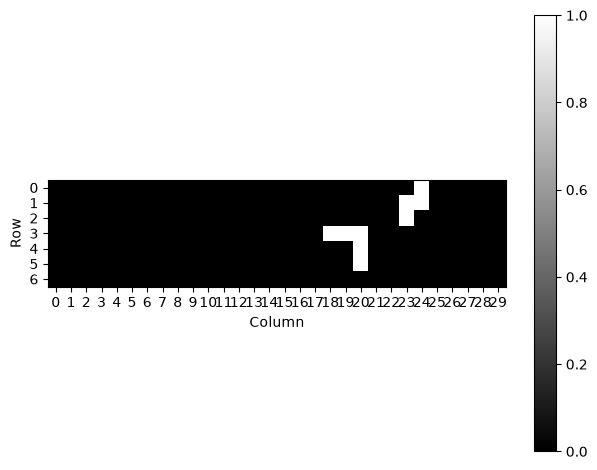

('A', 625)


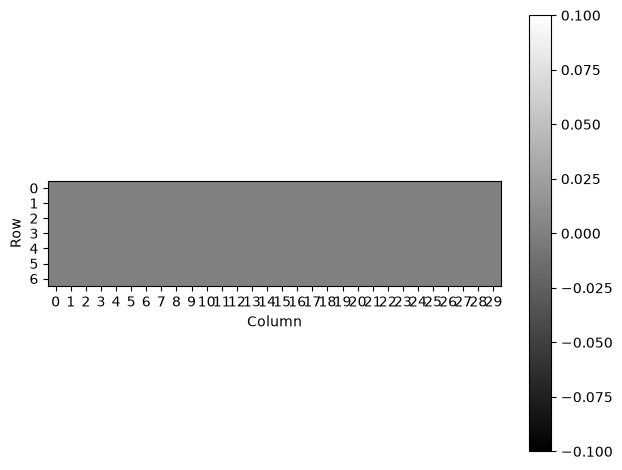

('A', 633)


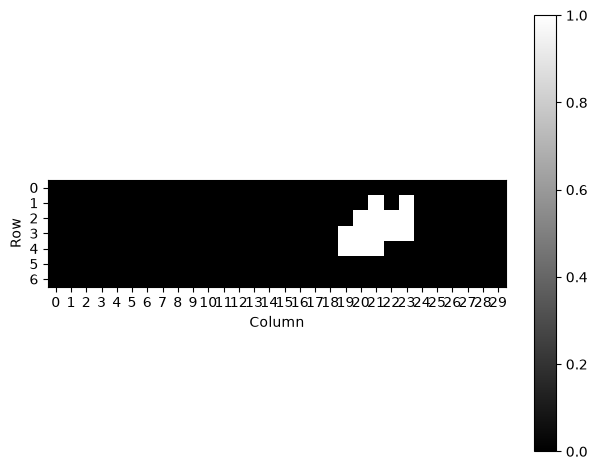

('A', 634)


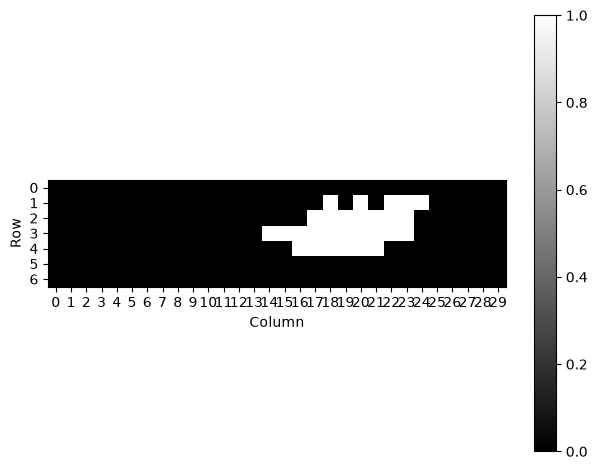

('A', 643)


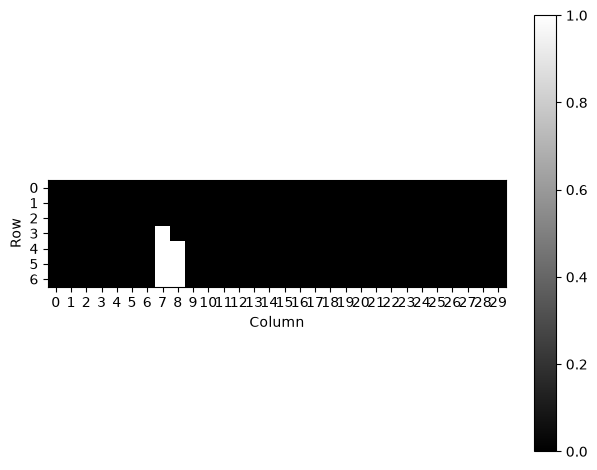

('A', 655)


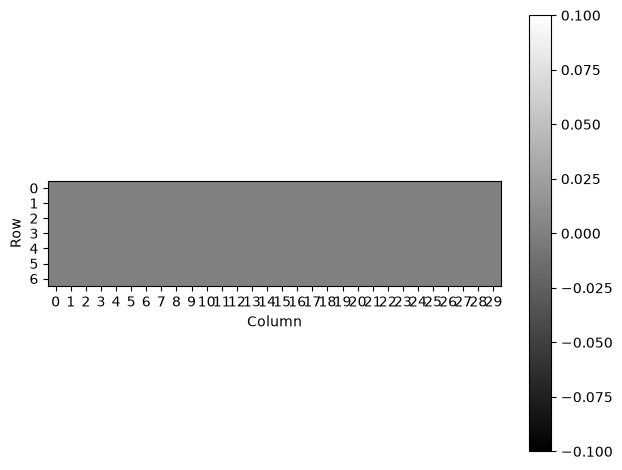

('A', 669)


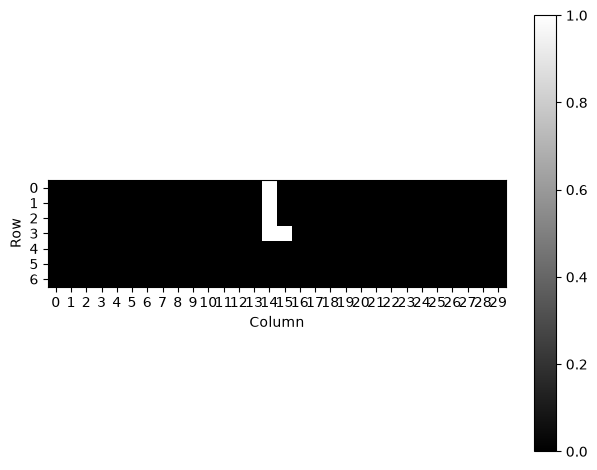

('A', 685)


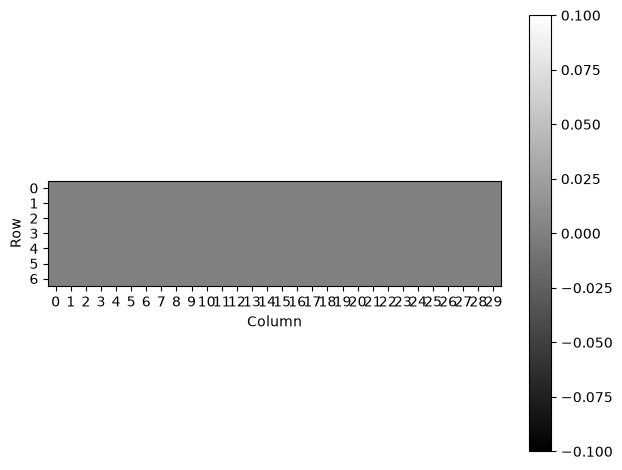

('A', 696)


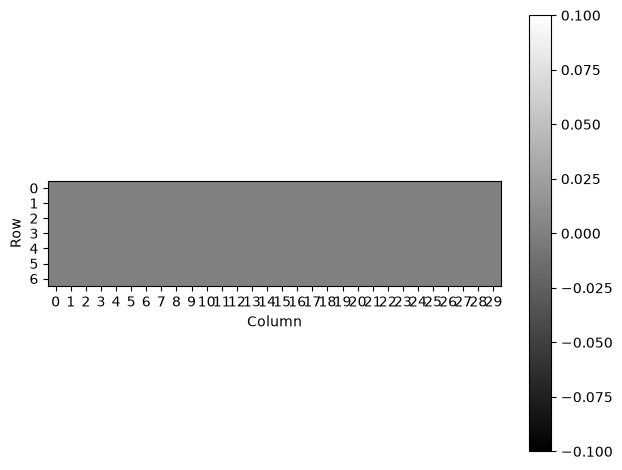

('A', 699)


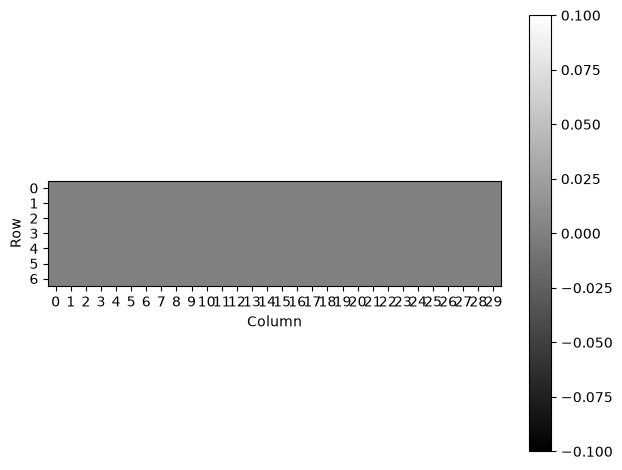

('A', 705)


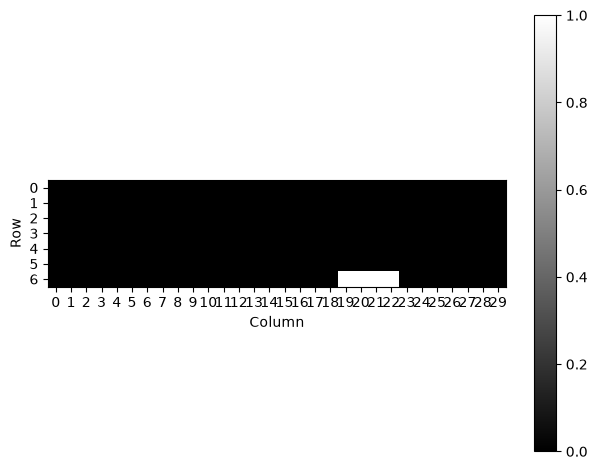

('A', 709)


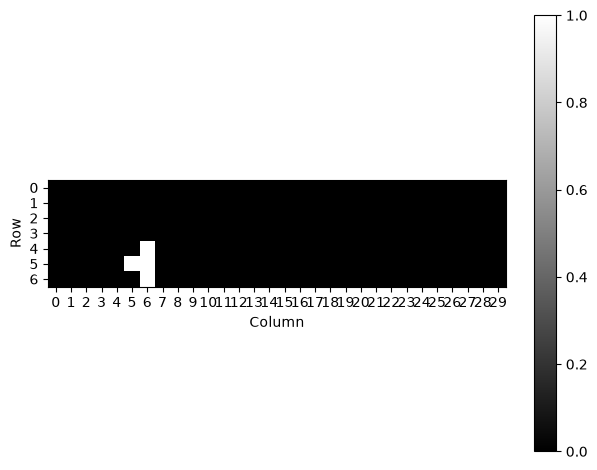

('A', 732)


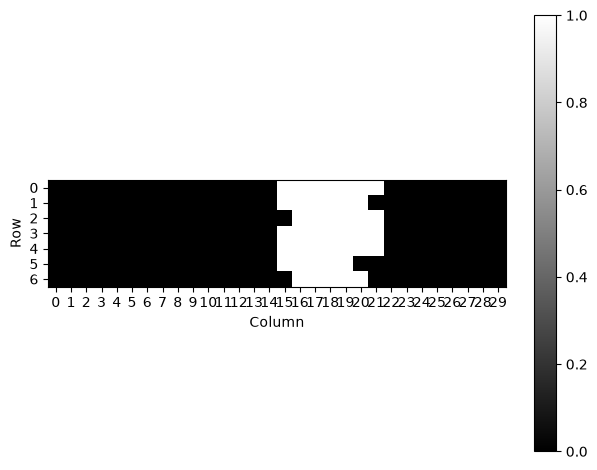

('A', 758)


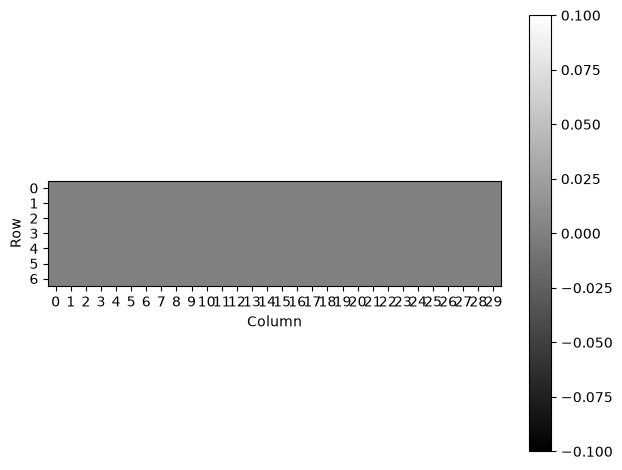

('A', 768)


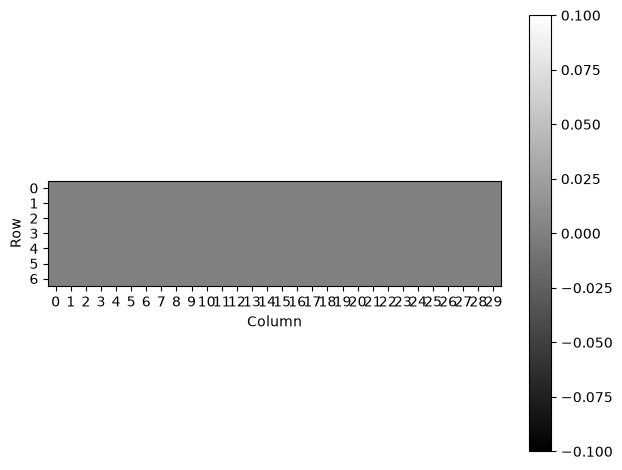

('A', 777)


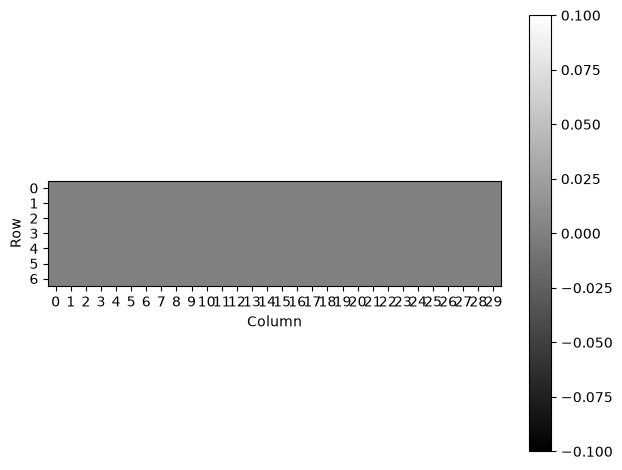

('A', 840)


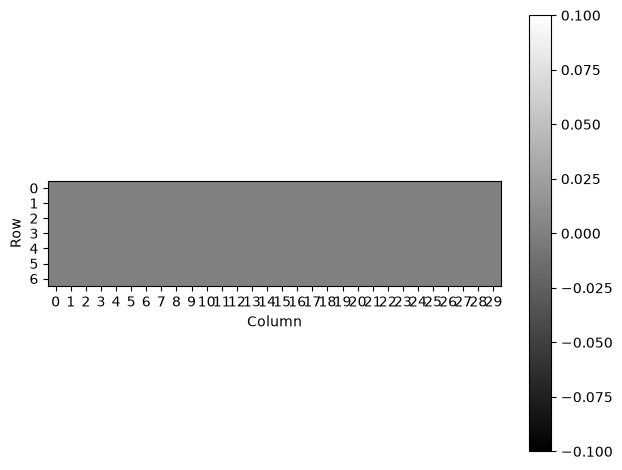

('A', 841)


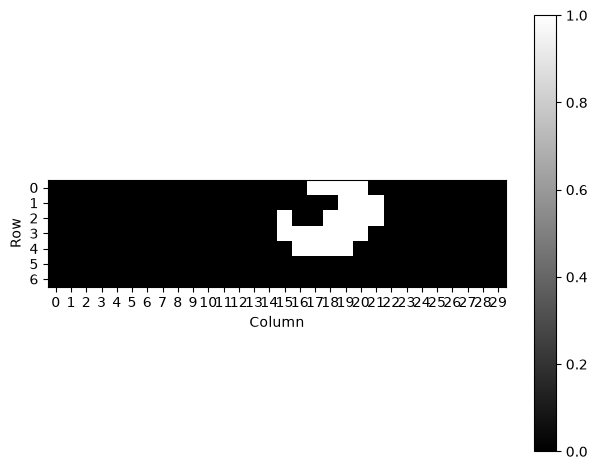

('A', 853)


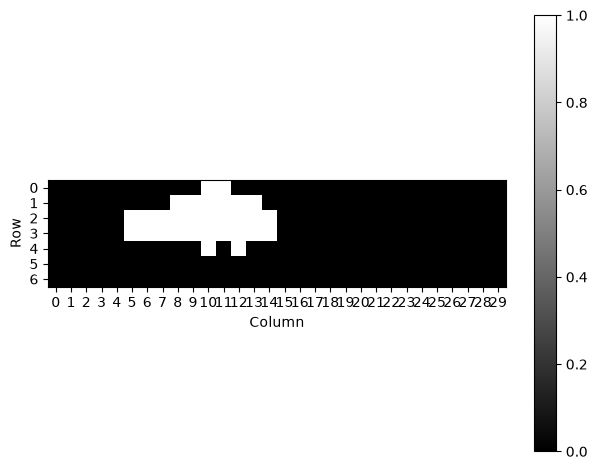

In [4]:
for index, rf in enumerate(rfs_by_probe[targetProbe]):
    print(RFunitPool[index])
    plot_2d_rfmap(rf, cmap="grey")

------------ Probe A ------------


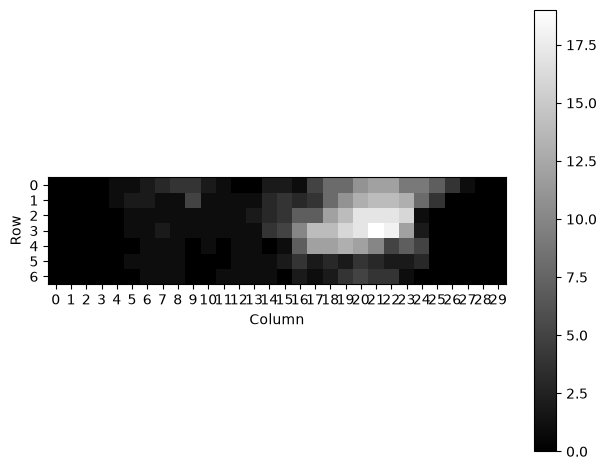

------------ All Probes ------------


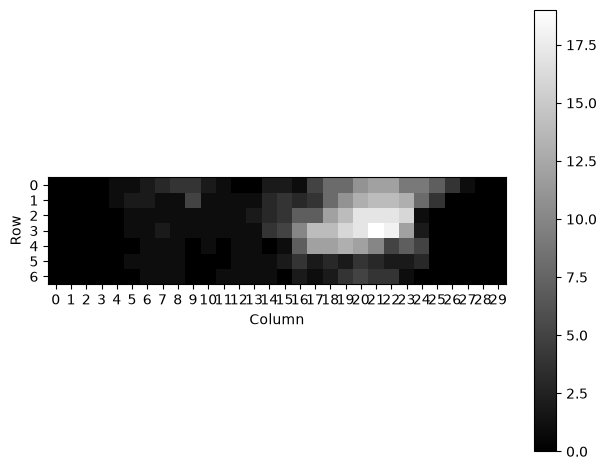

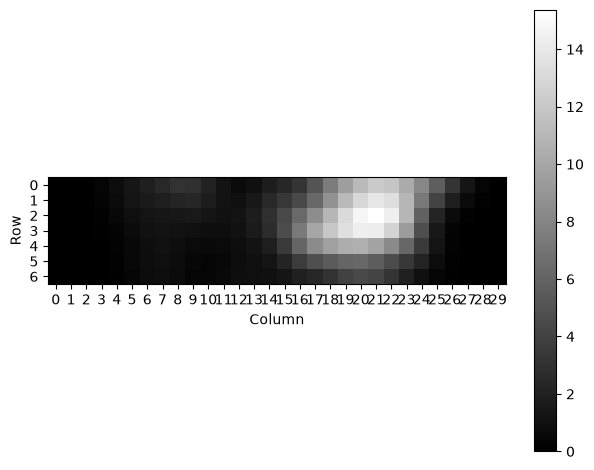

(<Figure size 640x480 with 2 Axes>, <Axes: xlabel='Column', ylabel='Row'>)

In [5]:
rf_counts_by_probe = {}
rf_counts = np.zeros(rf_all.shape[1:], dtype=np.int64)

for probe in probeList:
    probe_counts = rfs_by_probe[probe].sum(axis=0, dtype=np.int64)
    rf_counts_by_probe[probe] = probe_counts
    rf_counts += probe_counts
    print("------------ Probe", probe, "------------")
    plot_2d_rfmap(probe_counts, cmap="grey")

rf_counts_smoothed = gaussian_filter(
    rf_counts.astype(float),
    sigma=(1.0, 1.0),
    mode="nearest",
)

print("------------ All Probes ------------")
plot_2d_rfmap(rf_counts, cmap="grey")
plot_2d_rfmap(rf_counts_smoothed, cmap="grey")

------------ Probe A ------------


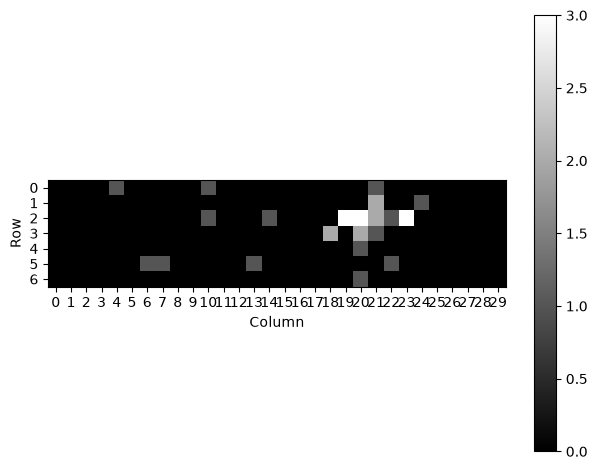

------------ All Probes ------------


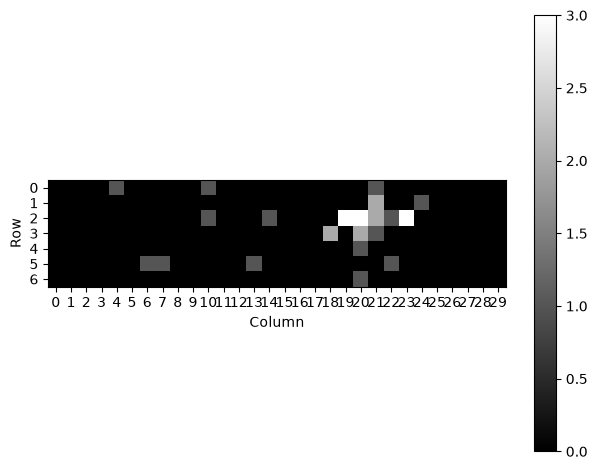

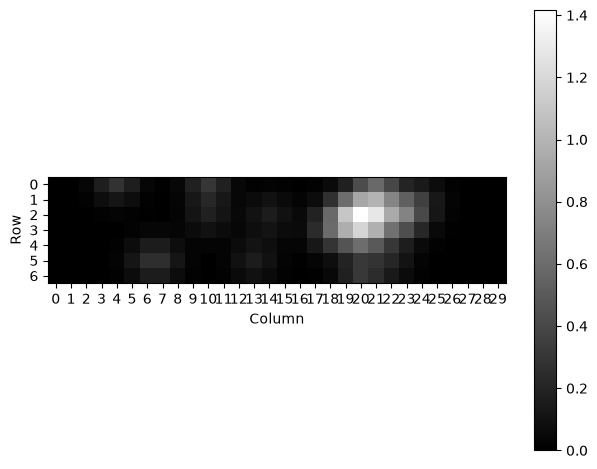

(<Figure size 640x480 with 2 Axes>, <Axes: xlabel='Column', ylabel='Row'>)

In [6]:
rf_counts_by_probe = {}
rf_counts = np.zeros(center_all.shape[1:], dtype=np.int64)

for probe in probeList:
    probe_counts = rf_centers_by_probe[probe].sum(axis=0, dtype=np.int64)
    rf_counts_by_probe[probe] = probe_counts
    rf_counts += probe_counts
    print("------------ Probe", probe, "------------")
    plot_2d_rfmap(probe_counts, cmap="grey")

rf_counts_smoothed = gaussian_filter(
    rf_counts.astype(float),
    sigma=(1.0, 1.0),
    mode="nearest",
)

print("------------ All Probes ------------")
plot_2d_rfmap(rf_counts, cmap="grey")
plot_2d_rfmap(rf_counts_smoothed, cmap="grey")

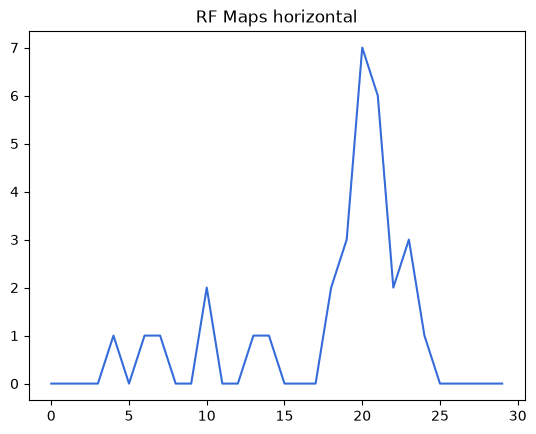

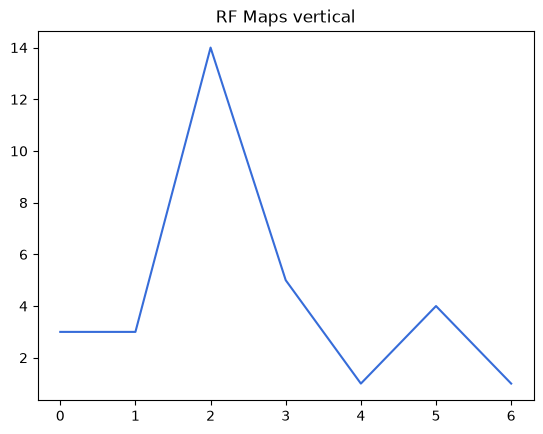

In [7]:
plt.plot(asrfmap(rf_counts).to_1d_array("x"))
plt.title("RF Maps horizontal")
plt.show()
plt.plot(asrfmap(rf_counts).to_1d_array("y"))
plt.title("RF Maps vertical")
plt.show()
